# National-Level Cost of Travel Index Calculation

This notebook loads multiple CSV files from BigQuery exports (2022-2025) and calculates the cost of a three-day weekend trip by state.

**Data Sources:**
- Accommodations: 2 nights (median per-transaction cost)
- Restaurants: 6 meals (4 breakfast/lunch at P35, 2 dinners at P65)
- Attractions: 2 days (median per-transaction cost)
- Retail: 1 day (median per-transaction cost)

In [18]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Load and Concatenate Data Files

Use glob to find all CSV files in each category folder and concatenate them.

In [2]:
# Define base path
base_path = '../national_data'

# Load Accommodations - all CSV files in accommodations folder
acc_files = glob.glob(os.path.join(base_path, 'accommodations', '*.csv'))
print(f"Found {len(acc_files)} accommodation files:")
for f in acc_files:
    print(f"  - {os.path.basename(f)}")

acc_dfs = [pd.read_csv(f) for f in acc_files]
acc = pd.concat(acc_dfs, ignore_index=True)

print(f"\nTotal accommodation records: {len(acc)}")
print(f"Date range: {acc['month_date'].min()} to {acc['month_date'].max()}")
print(f"Unique months: {acc['month_date'].nunique()}")

Found 4 accommodation files:
  - accommodations_national_2024.csv
  - accommodations_national_2025.csv
  - accommodations_national_2022.csv
  - accommodations_national_2023.csv

Total accommodation records: 46
Date range: 2022-01-01 to 2025-10-01
Unique months: 46


In [3]:
# Quick check of accommodations data
acc.head()

,geography_level,month_date,accommodation_cost,transaction_count,unique_visitors,min_cost,max_cost,q25,q75,data_quality_flag,period_start,period_end,calculation_timestamp
0,US,2024-01-01,183.770004,284413,146212,59.910000,1680.020020,113.790001,337.029999,SINGLE_MONTH,2024-01-01,2024-12-31,2025-12-01 03:13:50.851074 UTC
1,US,2024-02-01,191.389999,309623,164410,60.029999,1727.569946,117.389999,345.170013,SINGLE_MONTH,2024-01-01,2024-12-31,2025-12-01 03:13:50.851074 UTC
2,US,2024-03-01,194.820007,369669,197657,59.990002,1647.989990,119.489998,352.480011,SINGLE_MONTH,2024-01-01,2024-12-31,2025-12-01 03:13:50.851074 UTC
3,US,2024-04-01,198.550003,358193,188913,60.340000,1608.150024,119.099998,360.579987,SINGLE_MONTH,2024-01-01,2024-12-31,2025-12-01 03:13:50.851074 UTC
4,US,2024-05-01,198.500000,372603,199508,60.599998,1635.900024,120.160004,353.549988,SINGLE_MONTH,2024-01-01,2024-12-31,2025-12-01 03:13:50.851074 UTC


In [4]:
# Load Attractions - all CSV files in attractions folder
att_files = glob.glob(os.path.join(base_path, 'attractions', '*.csv'))
print(f"Found {len(att_files)} attraction files:")
for f in att_files:
    print(f"  - {os.path.basename(f)}")

att_dfs = [pd.read_csv(f) for f in att_files]
att = pd.concat(att_dfs, ignore_index=True)

print(f"\nTotal attraction records: {len(att)}")
print(f"Date range: {att['month_date'].min()} to {att['month_date'].max()}")
print(f"Unique months: {att['month_date'].nunique()}")

Found 4 attraction files:
  - attraction_national_2022.csv
  - attractions_national_2023.csv
  - attractions_national_2024.csv
  - attractions_national_2025.csv

Total attraction records: 46
Date range: 2022-01-01 to 2025-10-01
Unique months: 46


In [6]:
# Load Restaurants - all CSV files in retaurants folder (note typo in folder name)
rest_files = glob.glob(os.path.join(base_path, 'restaurants', '*.csv'))
print(f"Found {len(rest_files)} restaurant files:")
for f in rest_files:
    print(f"  - {os.path.basename(f)}")

rest_dfs = [pd.read_csv(f) for f in rest_files]
rest = pd.concat(rest_dfs, ignore_index=True)

print(f"\nTotal restaurant records: {len(rest)}")
print(f"Date range: {rest['month_date'].min()} to {rest['month_date'].max()}")
print(f"Unique months: {rest['month_date'].nunique()}")

Found 4 restaurant files:
  - restaurant_national_2024.csv
  - restaurant_national_2025.csv
  - restaurant_national_2022.csv
  - restaurant_national_2023.csv

Total restaurant records: 46
Date range: 2022-01-01 to 2025-10-01
Unique months: 46


In [7]:
# Load Retail - all CSV files in retail folder
ret_files = glob.glob(os.path.join(base_path, 'retail', '*.csv'))
print(f"Found {len(ret_files)} retail files:")
for f in ret_files:
    print(f"  - {os.path.basename(f)}")

ret_dfs = [pd.read_csv(f) for f in ret_files]
ret = pd.concat(ret_dfs, ignore_index=True)

print(f"\nTotal retail records: {len(ret)}")
print(f"Date range: {ret['month_date'].min()} to {ret['month_date'].max()}")
print(f"Unique months: {ret['month_date'].nunique()}")

Found 4 retail files:
  - retail_national_2022.csv
  - retail_national_2023.csv
  - retail_national_2024.csv
  - retail_national_2025.csv

Total retail records: 46
Date range: 2022-01-01 to 2025-10-01
Unique months: 46


## 2. Data Quality Check

Verify that all datasets have consistent months and check for any data issues.

In [8]:
# Check unique months in each dataset
print("Unique months by category:")
print(f"Accommodations: {sorted(acc['month_date'].unique())}")
print(f"Attractions: {sorted(att['month_date'].unique())}")
print(f"Restaurants: {sorted(rest['month_date'].unique())}")
print(f"Retail: {sorted(ret['month_date'].unique())}")

Unique months by category:
Accommodations: ['2022-01-01', '2022-02-01', '2022-03-01', '2022-04-01', '2022-05-01', '2022-06-01', '2022-07-01', '2022-08-01', '2022-09-01', '2022-10-01', '2022-11-01', '2022-12-01', '2023-01-01', '2023-02-01', '2023-03-01', '2023-04-01', '2023-05-01', '2023-06-01', '2023-07-01', '2023-08-01', '2023-09-01', '2023-10-01', '2023-11-01', '2023-12-01', '2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01', '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01', '2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01', '2025-05-01', '2025-06-01', '2025-07-01', '2025-08-01', '2025-09-01', '2025-10-01']
Attractions: ['2022-01-01', '2022-02-01', '2022-03-01', '2022-04-01', '2022-05-01', '2022-06-01', '2022-07-01', '2022-08-01', '2022-09-01', '2022-10-01', '2022-11-01', '2022-12-01', '2023-01-01', '2023-02-01', '2023-03-01', '2023-04-01', '2023-05-01', '2023-06-01', '2023-07-01', '2023-08-01', '2023-09-01', '202

## 3. Merge Data Sources

Join all four datasets on state and month_date to create a unified dataset.

In [10]:
# Merge accommodations and attractions
merge_1 = pd.merge(
    acc, 
    att, 
    how='left', 
    on=['month_date'], 
    suffixes=('_acc', '_att')
)

print(f"After merging accommodations + attractions: {len(merge_1)} records")

After merging accommodations + attractions: 46 records


In [11]:
# Merge restaurants and retail
merge_2 = pd.merge(
    rest, 
    ret, 
    how='left', 
    on=[ 'month_date'], 
    suffixes=('_rest', '_ret')
)

print(f"After merging restaurants + retail: {len(merge_2)} records")

After merging restaurants + retail: 46 records


In [12]:
# Final merge to combine all four data sources
final = pd.merge(
    merge_1, 
    merge_2, 
    how='left', 
    on=[ 'month_date']
)

print(f"Final merged dataset: {len(final)} records")
print(f"Date range: {final['month_date'].min()} to {final['month_date'].max()}")
print(f"Unique months: {final['month_date'].nunique()}")

Final merged dataset: 46 records
Date range: 2022-01-01 to 2025-10-01
Unique months: 46


In [13]:
# Check merged data structure
final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 67 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   geography_level_acc                 46 non-null     object 
 1   month_date                          46 non-null     object 
 2   accommodation_cost                  46 non-null     float64
 3   transaction_count_x                 46 non-null     int64  
 4   unique_visitors_acc                 46 non-null     int64  
 5   min_cost                            46 non-null     float64
 6   max_cost                            46 non-null     float64
 7   q25                                 46 non-null     float64
 8   q75                                 46 non-null     float64
 9   data_quality_flag_acc               46 non-null     object 
 10  period_start_acc                    46 non-null     object 
 11  period_end_acc                      46 non-null

## 4. Calculate Cost of Travel Index

Apply basket multiplication:
- 2 nights accommodation
- 4 breakfast/lunch meals
- 2 dinner meals
- 2 days attractions
- 1 day retail (x2 for couple)

In [14]:
# Select and rename key columns for clarity
cti = final[[
    'month_date', 
    'accommodation_cost', 
    'attraction_cost', 
    'breakfast_lunch_cost', 
    'dinner_cost', 
    'median_meal_cost', 
    'retail_cost'
]].copy()

cti.head()

,month_date,accommodation_cost,attraction_cost,breakfast_lunch_cost,dinner_cost,median_meal_cost,retail_cost
0,2024-01-01,183.770004,23.16,19.15,37.520000,26.790001,33.380001
1,2024-02-01,191.389999,24.15,19.02,37.730000,26.760000,36.590000
2,2024-03-01,194.820007,25.74,19.50,38.950001,27.500000,38.130001
3,2024-04-01,198.550003,24.98,18.17,36.150002,25.510000,37.529999
4,2024-05-01,198.500000,25.34,19.23,38.130001,26.910000,37.509998


In [15]:
# Calculate total cost per trip (3-day weekend for a couple)
cti['cost_per_trip'] = (
    (cti['accommodation_cost'] * 2) +      # 2 nights
    (cti['attraction_cost'] * 2) +         # 2 days of attractions
    (cti['breakfast_lunch_cost'] * 4) +    # 4 breakfast/lunch meals
    (cti['dinner_cost'] * 2) +             # 2 dinner meals
    (cti['retail_cost'] * 2)               # 2 days of retail (couple)
)

print("Cost calculation complete!")
cti.head()

Cost calculation complete!


,month_date,accommodation_cost,attraction_cost,breakfast_lunch_cost,dinner_cost,median_meal_cost,retail_cost,cost_per_trip
0,2024-01-01,183.770004,23.16,19.15,37.520000,26.790001,33.380001,632.260010
1,2024-02-01,191.389999,24.15,19.02,37.730000,26.760000,36.590000,655.799999
2,2024-03-01,194.820007,25.74,19.50,38.950001,27.500000,38.130001,673.280018
3,2024-04-01,198.550003,24.98,18.17,36.150002,25.510000,37.529999,667.100006
4,2024-05-01,198.500000,25.34,19.23,38.130001,26.910000,37.509998,675.879997


## 5. Summary Statistics and Validation

In [17]:
# Show cost range by component
print("Cost per trip statistics:")
print(cti['cost_per_trip'].describe())

print("\nComponent cost ranges:")
print(f"Accommodation (2 nights): ${cti['accommodation_cost'].min():.2f} - ${cti['accommodation_cost'].max():.2f}")
print(f"Attractions (2 days): ${cti['attraction_cost'].min():.2f} - ${cti['attraction_cost'].max():.2f}")
print(f"Breakfast/Lunch (each): ${cti['breakfast_lunch_cost'].min():.2f} - ${cti['breakfast_lunch_cost'].max():.2f}")
print(f"Dinner (each): ${cti['dinner_cost'].min():.2f} - ${cti['dinner_cost'].max():.2f}")
print(f"Retail (per day): ${cti['retail_cost'].min():.2f} - ${cti['retail_cost'].max():.2f}")

Cost per trip statistics:
count     46.000000
mean     665.859567
std       22.289540
min      607.400005
25%      651.894996
50%      667.930008
75%      679.719995
max      703.160015
Name: cost_per_trip, dtype: float64

Component cost ranges:
Accommodation (2 nights): $170.58 - $205.63
Attractions (2 days): $22.24 - $27.26
Breakfast/Lunch (each): $18.17 - $21.19
Dinner (each): $35.09 - $42.40
Retail (per day): $33.38 - $40.18


<Axes: xlabel='month_date', ylabel='cost_per_trip'>

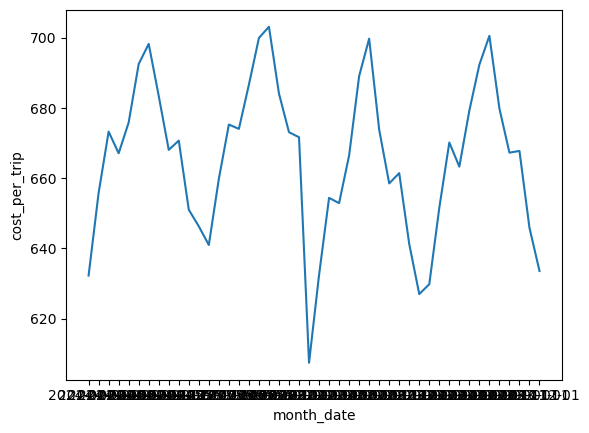

In [19]:
sns.lineplot(data=cti, x='month_date', y='cost_per_trip')

## 8. Export Final Dataset

In [20]:
# Export to CSV
output_filename = '../output/cti_national_2022-2025.csv'

# Create output directory if it doesn't exist
os.makedirs('../output', exist_ok=True)

cti.to_csv(output_filename, index=False)
print(f"\nData exported successfully to: {output_filename}")
print(f"Total records: {len(cti)}")
print(f"File size: {os.path.getsize(output_filename) / 1024:.2f} KB")


Data exported successfully to: ../output/cti_national_2022-2025.csv
Total records: 46
File size: 6.20 KB


In [ ]:
# Display final preview
print("\nFinal dataset preview (first 20 rows):")
cti.head(20)